# MIMII Sound Anomaly Detection — Exploratory Data Analysis

**Dataset:** MIMII (Malfunctioning Industrial Machine Investigation and Inspection)  
**Machine type:** Fan (−6 dB SNR split)  
**Task:** Unsupervised / semi-supervised anomaly detection — models are trained **only on normal sounds** and must flag anomalous ones at inference time.

## Dataset layout

```
fan/
  id_00/
    normal/      ← training pool (only these are used to fit models)
    abnormal/    ← test set (labels withheld at train time)
  id_02/ ...
  id_04/ ...
  id_06/ ...
```

Each file is a **10-second, 16 kHz, 8-channel** recording from a circular microphone array. The −6 dB split is the hardest: significant background noise is mixed in, simulating a realistic factory floor.

In [4]:
# ── imports ──────────────────────────────────────────────────────────────────
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Audio, display

# ── global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('fan')   # adjust if data lives elsewhere
MACHINE_IDS = ['id_00', 'id_02', 'id_04', 'id_06']
SR = 16_000               # native sample rate
CHANNEL = 0               # which mic channel to use (0–7); channel 0 is conventional

## 1 — Dataset inventory

Before touching audio, we count files and build a manifest DataFrame.  
This is the ground truth reference for every downstream split.

In [5]:
records = []
for machine_id in MACHINE_IDS:
    for label in ('normal', 'abnormal'):
        folder = DATA_ROOT / machine_id / label
        for wav in sorted(folder.glob('*.wav')):
            records.append({'machine_id': machine_id, 'label': label, 'path': wav})

manifest = pd.DataFrame(records)
manifest['is_anomaly'] = (manifest['label'] == 'abnormal').astype(int)

print(f"Total files : {len(manifest):,}")
print()
print(manifest.groupby(['machine_id', 'label']).size().unstack(fill_value=0).assign(
    anomaly_rate=lambda d: (d['abnormal'] / (d['normal'] + d['abnormal'])).map('{:.1%}'.format)
))

Total files : 5,536

label       abnormal  normal anomaly_rate
machine_id                               
id_00            407     997        29.0%
id_02            359    1016        26.1%
id_04            348    1033        25.2%
id_06            361    1015        26.2%


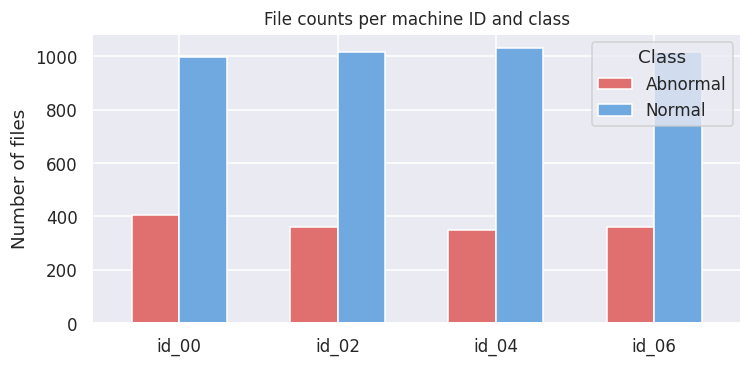

In [6]:
# ── bar chart: file counts per ID and class ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
counts = manifest.groupby(['machine_id', 'label']).size().unstack()
counts.plot(kind='bar', ax=ax, color=['#e07070', '#70a8e0'], edgecolor='white', width=0.6)
ax.set_title('File counts per machine ID and class')
ax.set_xlabel('')
ax.set_ylabel('Number of files')
ax.legend(title='Class', labels=['Abnormal', 'Normal'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Normal samples outnumber abnormal roughly 3:1 across all IDs — a deliberate design choice reflecting real deployment conditions where faults are rare.  
This imbalance means **accuracy is a misleading metric**; we will use AUC-ROC throughout.

## 2 — Loading audio & channel strategy

Each file holds **8 channels** recorded simultaneously by a circular mic array.  
The MIMII authors do not specify a canonical channel for downstream tasks.  
Three common strategies:

| Strategy | Code | Notes |
|---|---|---|
| Single channel | `audio[:, 0]` | Fast; loses spatial info |
| Mono mix | `audio.mean(axis=1)` | Averages out directional noise |
| Multi-channel | keep all | More information; higher compute cost |

We start with **channel 0** (simplest), verify there is no silent or pathological channel, then revisit.

In [7]:
def load_mono(path, channel=CHANNEL, sr=SR):
    """Load a single channel from a MIMII WAV file. Returns 1-D float32 array."""
    audio, file_sr = sf.read(path, dtype='float32')
    assert file_sr == sr, f"Unexpected sample rate {file_sr} in {path}"
    return audio[:, channel] if audio.ndim == 2 else audio

# Quick sanity check on one file per ID/class
for row in manifest.groupby(['machine_id', 'label']).first().itertuples():
    y = load_mono(row.path)
    print(f"{row.Index} | shape: {y.shape} | duration: {len(y)/SR:.1f}s "
          f"| RMS: {np.sqrt(np.mean(y**2)):.4f} | max: {np.abs(y).max():.4f}")

('id_00', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0134 | max: 0.0555
('id_00', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0107 | max: 0.0518
('id_02', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0107 | max: 0.0474
('id_02', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0113 | max: 0.0490
('id_04', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0118 | max: 0.0532
('id_04', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0110 | max: 0.0474
('id_06', 'abnormal') | shape: (160000,) | duration: 10.0s | RMS: 0.0102 | max: 0.0450
('id_06', 'normal') | shape: (160000,) | duration: 10.0s | RMS: 0.0114 | max: 0.0484


### 2.1 — Channel energy comparison

Check whether any channel is systematically quieter (broken mic) across a sample of files.

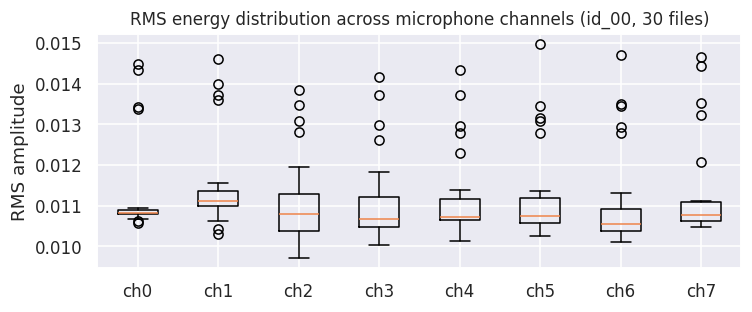

In [8]:
sample_paths = manifest[manifest['machine_id'] == 'id_00']['path'].sample(30, random_state=SEED).tolist()

rms_per_channel = np.zeros((len(sample_paths), 8))
for i, p in enumerate(sample_paths):
    audio, _ = sf.read(p, dtype='float32')
    rms_per_channel[i] = np.sqrt(np.mean(audio**2, axis=0))

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(rms_per_channel, tick_labels=[f'ch{i}' for i in range(8)])
ax.set_title('RMS energy distribution across microphone channels (id_00, 30 files)')
ax.set_ylabel('RMS amplitude')
plt.tight_layout()
plt.show()

If all channels show similar energy, picking channel 0 is fine.  
If one channel is clearly lower, avoid it in the `CHANNEL` constant above.

## 3 — Listening to the data

Always listen before modeling. It builds intuition and catches loading bugs.

In [9]:
for machine_id in ['id_00']:          # expand to other IDs as desired
    for label in ('normal', 'abnormal'):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[0]
        y = load_mono(path)
        print(f"▶  {machine_id} / {label}")
        display(Audio(y, rate=SR))

▶  id_00 / normal


▶  id_00 / abnormal


## 4 — Waveform visualization

Plot the raw amplitude over time for one normal and one abnormal clip.  
Fan anomalies are often intermittent — look for bursts or amplitude changes.

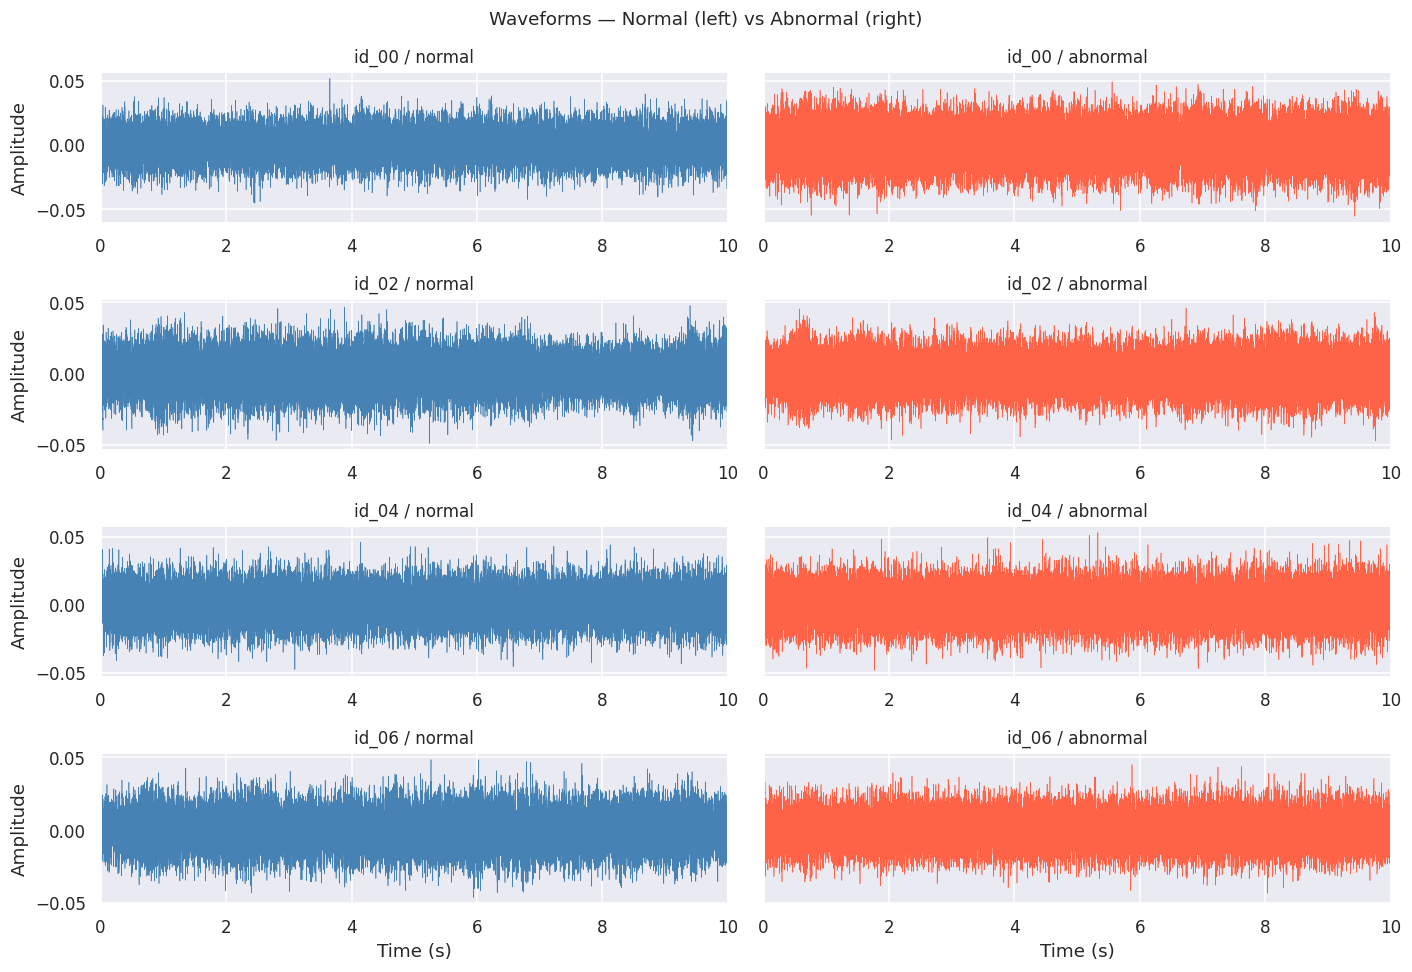

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharey='row')
fig.suptitle('Waveforms — Normal (left) vs Abnormal (right)', fontsize=12)

t = np.linspace(0, 10, SR * 10)

for row_idx, machine_id in enumerate(MACHINE_IDS):
    for col_idx, label in enumerate(('normal', 'abnormal')):
        path = manifest[(manifest['machine_id'] == machine_id) &
                        (manifest['label'] == label)]['path'].iloc[0]
        y = load_mono(path)
        ax = axes[row_idx, col_idx]
        ax.plot(t, y, linewidth=0.4, color='steelblue' if label == 'normal' else 'tomato')
        ax.set_title(f'{machine_id} / {label}')
        ax.set_xlim(0, 10)
        if col_idx == 0:
            ax.set_ylabel('Amplitude')
        if row_idx == 3:
            ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 5 — Spectral analysis

The waveform alone rarely reveals anomalies — they often appear as shifts in specific frequency bands.  
We will look at three representations:

1. **Short-Time Fourier Transform (STFT)** spectrogram — raw frequency content vs. time  
2. **Log-mel spectrogram** — perceptually scaled, the standard input for deep learning models  
3. **MFCC** — compact spectral envelope, useful for classical ML baselines

In [11]:
# ── feature extraction helpers ────────────────────────────────────────────────
N_FFT   = 1024   # FFT window size → frequency resolution
HOP_LEN = 512    # hop size → time resolution
N_MELS  = 64     # mel filter bank size
N_MFCC  = 40     # number of MFCC coefficients

def compute_log_mel(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN, n_mels=N_MELS):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                        hop_length=hop_length, n_mels=n_mels)
    return librosa.power_to_db(S, ref=np.max)

def compute_mfcc(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN,
                  n_mels=N_MELS, n_mfcc=N_MFCC):
    return librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                  n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

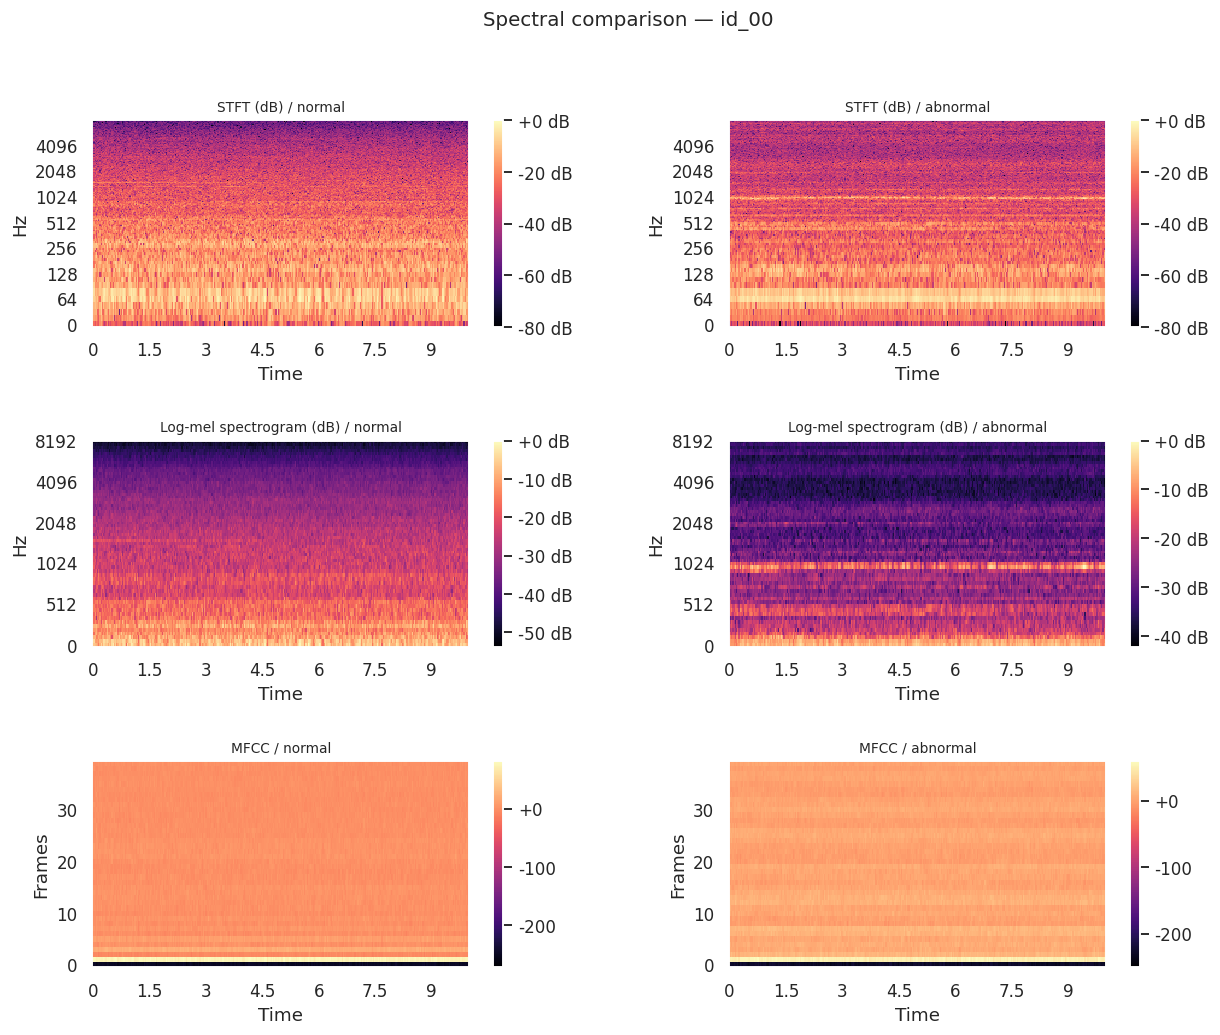

In [12]:
# ── plot STFT + log-mel + MFCC for id_00 normal vs abnormal ──────────────────
machine_id = 'id_00'
pairs = {}
for label in ('normal', 'abnormal'):
    path = manifest[(manifest['machine_id'] == machine_id) &
                    (manifest['label'] == label)]['path'].iloc[0]
    pairs[label] = load_mono(path)

fig = plt.figure(figsize=(13, 10))
fig.suptitle(f'Spectral comparison — {machine_id}', fontsize=13)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

rep_funcs = {
    'STFT (dB)': lambda y: librosa.amplitude_to_db(
                               np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN)), ref=np.max),
    'Log-mel spectrogram (dB)': compute_log_mel,
    'MFCC': compute_mfcc,
}

for row_idx, (rep_name, func) in enumerate(rep_funcs.items()):
    for col_idx, label in enumerate(('normal', 'abnormal')):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        M = func(pairs[label])
        img = librosa.display.specshow(
            M, sr=SR, hop_length=HOP_LEN,
            x_axis='time',
            y_axis='mel' if 'mel' in rep_name.lower() else
                    'log'  if 'STFT' in rep_name else
                    'frames',
            ax=ax, cmap='magma'
        )
        ax.set_title(f'{rep_name} / {label}', fontsize=9)
        plt.colorbar(img, ax=ax, format='%+2.0f dB' if 'MFCC' not in rep_name else '%+.0f')

plt.show()

## 6 — Statistical summary of the feature space

Before training any model, it is worth understanding how separable the two classes are *in feature space*.  
We compute a summary statistics vector per clip (mean + std of each MFCC coefficient) — this is the standard compact descriptor used in classical pipelines.  
If the classes are already linearly separable with this descriptor, a simple classifier will do. If not, we need a more powerful representation.

In [13]:
from tqdm.notebook import tqdm

def extract_summary_features(path):
    """Returns a 1-D feature vector: [mean(MFCC), std(MFCC)] concatenated."""
    y = load_mono(path)
    mfcc = compute_mfcc(y)           # shape: (n_mfcc, T)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

print("Extracting summary MFCC features for all files...")
features = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    features.append(extract_summary_features(row['path']))

X = np.array(features, dtype=np.float32)
y_labels = manifest['is_anomaly'].values
print(f"Feature matrix shape: {X.shape}")

Extracting summary MFCC features for all files...


  0%|          | 0/5536 [00:00<?, ?it/s]

Feature matrix shape: (5536, 80)


### 6.1 — PCA visualization

PCA projects the high-dimensional feature vectors to 2D to let us see cluster structure.  
We colour by class and use marker shapes for machine ID.

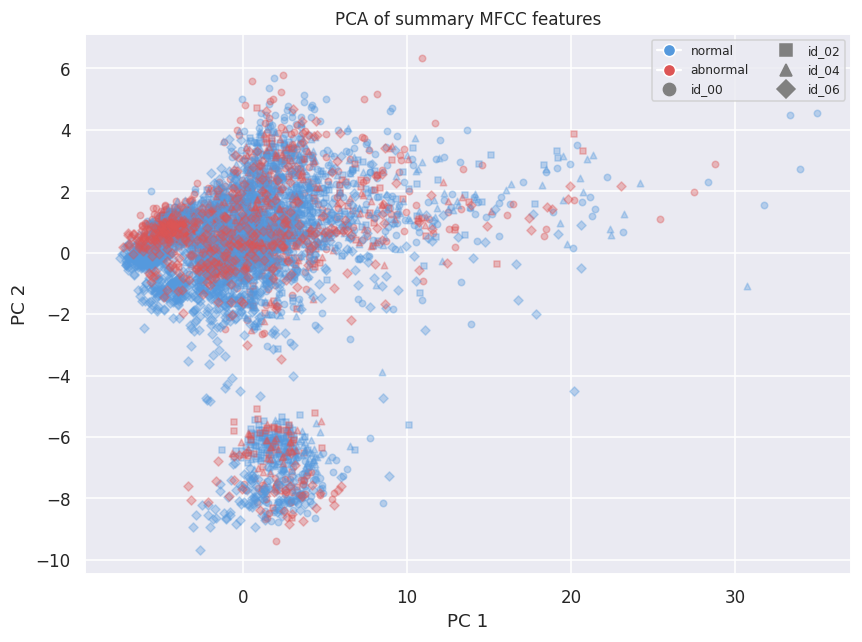

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
markers = {'id_00': 'o', 'id_02': 's', 'id_04': '^', 'id_06': 'D'}
colors  = {'normal': '#5599dd', 'abnormal': '#dd5555'}

for machine_id in MACHINE_IDS:
    for label in ('normal', 'abnormal'):
        mask = (manifest['machine_id'] == machine_id) & (manifest['label'] == label)
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=colors[label], marker=markers[machine_id],
            alpha=0.35, s=18,
            label=f'{machine_id}/{label}' if label == 'normal' or machine_id == 'id_00' else '_nolegend_'
        )

ax.set_title('PCA of summary MFCC features')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
# Custom legend: class colour + ID shape
from matplotlib.lines import Line2D
legend_elements = (
    [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=lbl)
     for lbl, c in colors.items()] +
    [Line2D([0],[0], marker=m, color='gray', markersize=8, label=mid, linestyle='None')
     for mid, m in markers.items()]
)
ax.legend(handles=legend_elements, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### 6.2 — Distribution of individual MFCC coefficients

Violin plots show whether the normal and abnormal distributions differ *coefficient by coefficient*.  
Coefficients where the distributions overlap heavily will not contribute useful signal.

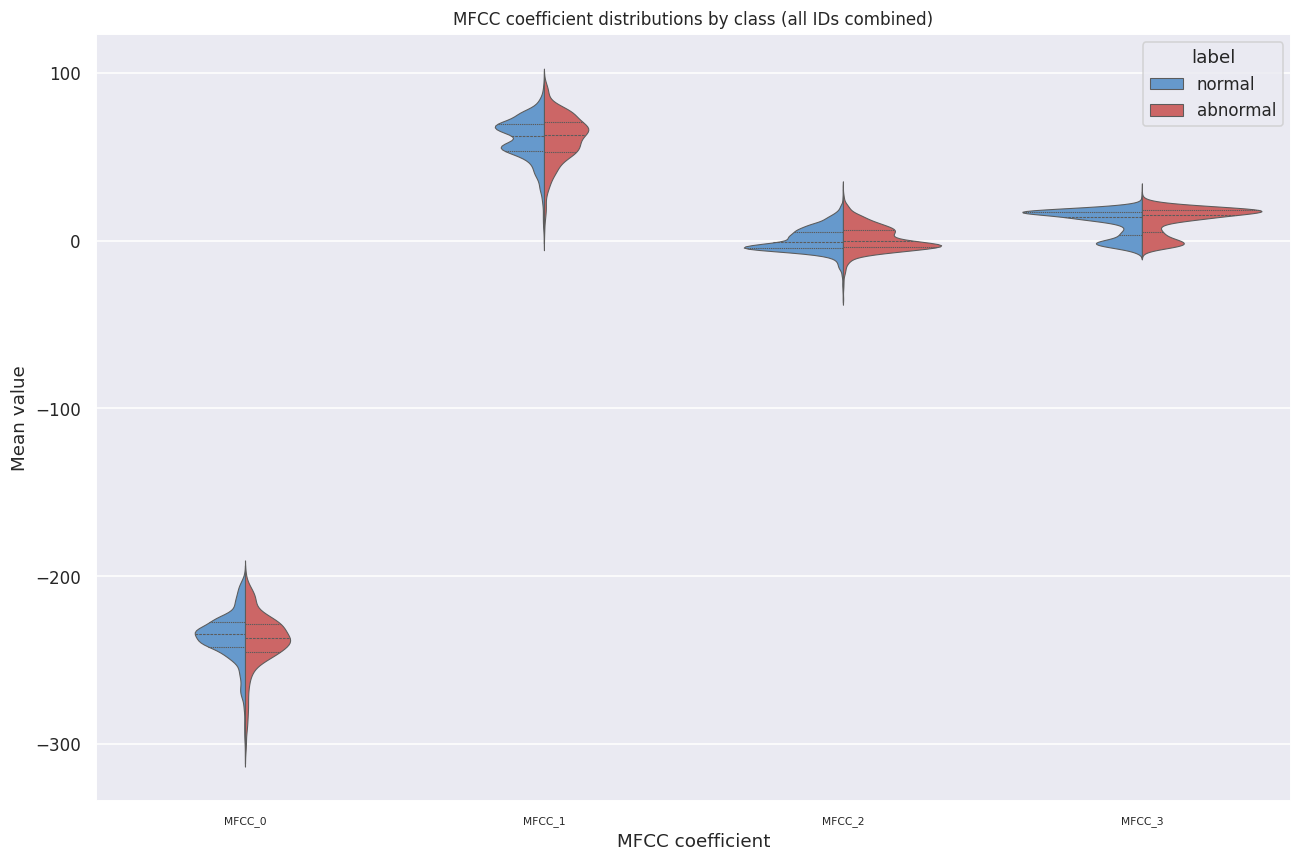

In [15]:
# Use mean of MFCC coefficients (first half of feature vector)
n_mfcc = 4
df_mfcc = pd.DataFrame(
    X[:, :n_mfcc],
    columns=[f'MFCC_{i}' for i in range(n_mfcc)]
)
df_mfcc['label'] = manifest['label'].values

df_long = df_mfcc.melt(id_vars='label', var_name='coefficient', value_name='mean')

fig, ax = plt.subplots(figsize=(12, 8))
sns.violinplot(
    data=df_long, x='coefficient', y='mean', hue='label',
    split=True, inner='quartile', palette={'normal': '#5599dd', 'abnormal': '#dd5555'},
    ax=ax, linewidth=0.7
)
ax.set_title('MFCC coefficient distributions by class (all IDs combined)')
ax.set_xlabel('MFCC coefficient')
ax.set_ylabel('Mean value')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

## 7 — Inter-machine-ID variability

MIMII contains four distinct fan units (id_00, id_02, id_04, id_06).  
They are **different physical machines** with potentially different operating points.  
This has a critical implication: **models must be trained and evaluated per machine ID**, not across all IDs, because a cross-ID model may just learn machine identity instead of normalcy.

Here we quantify how spread-out normal sounds are across IDs.

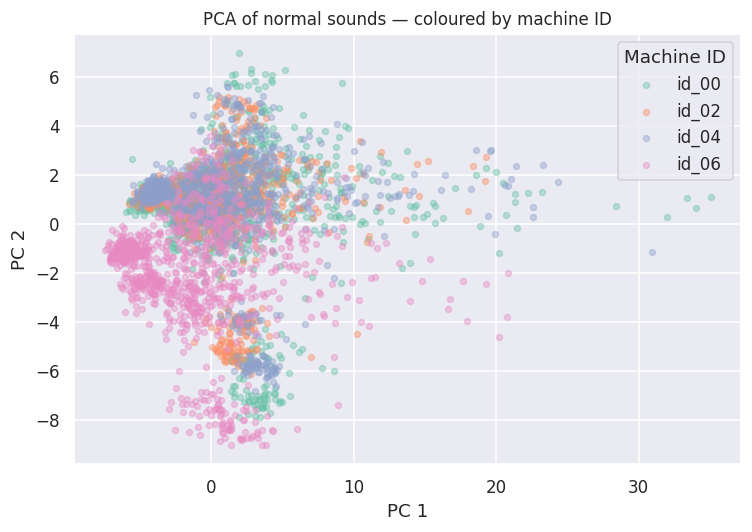

In [16]:
normal_mask = manifest['label'] == 'normal'
X_normal = X_scaled[normal_mask]
ids_normal = manifest['machine_id'].values[normal_mask]

X_pca_n = PCA(n_components=2, random_state=SEED).fit_transform(X_normal)

fig, ax = plt.subplots(figsize=(7, 5))
palette = sns.color_palette('Set2', 4)
for i, mid in enumerate(MACHINE_IDS):
    mask = ids_normal == mid
    ax.scatter(X_pca_n[mask, 0], X_pca_n[mask, 1],
               c=[palette[i]], alpha=0.4, s=15, label=mid)

ax.set_title('PCA of normal sounds — coloured by machine ID')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(title='Machine ID')
plt.tight_layout()
plt.show()

If the clusters are well-separated, separate per-ID models are mandatory.  
If they overlap strongly, a shared feature extractor with ID-specific heads may work.

## 8 — Energy & duration sanity checks

Check that all clips have consistent length and no silent/clipped recordings.

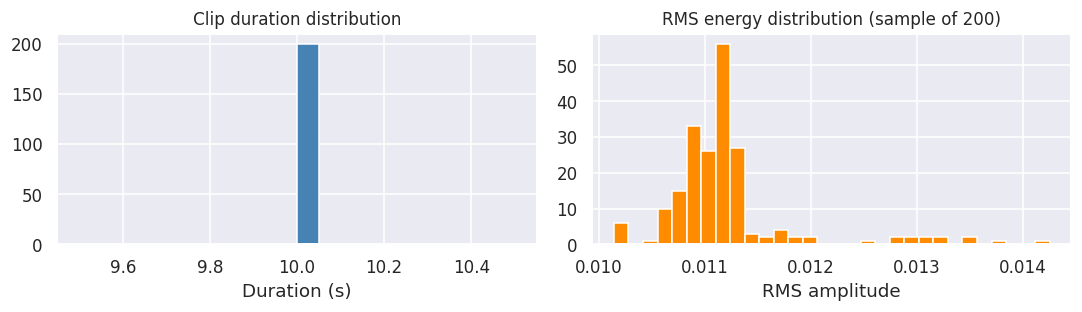

Duration: min=10.00s  max=10.00s
RMS    : min=0.0101  max=0.0143  (near-silence threshold < 0.001 would flag issues)


In [17]:
# Sample 200 files for a quick check (full scan would take a few minutes)
sample = manifest.sample(200, random_state=SEED)

durations, rms_vals = [], []
for _, row in sample.iterrows():
    y = load_mono(row['path'])
    durations.append(len(y) / SR)
    rms_vals.append(float(np.sqrt(np.mean(y**2))))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(durations, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Clip duration distribution')
axes[0].set_xlabel('Duration (s)')

axes[1].hist(rms_vals, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('RMS energy distribution (sample of 200)')
axes[1].set_xlabel('RMS amplitude')

plt.tight_layout()
plt.show()

print(f"Duration: min={min(durations):.2f}s  max={max(durations):.2f}s")
print(f"RMS    : min={min(rms_vals):.4f}  max={max(rms_vals):.4f}  "
      f"(near-silence threshold < 0.001 would flag issues)")

## 9 — Log-mel spectrogram batch preview

A grid of spectrograms gives a qualitative feel for intra-class variability.  
If normal sounds look highly consistent, an autoencoder will train easily.  
High variability within the normal class makes the task harder.

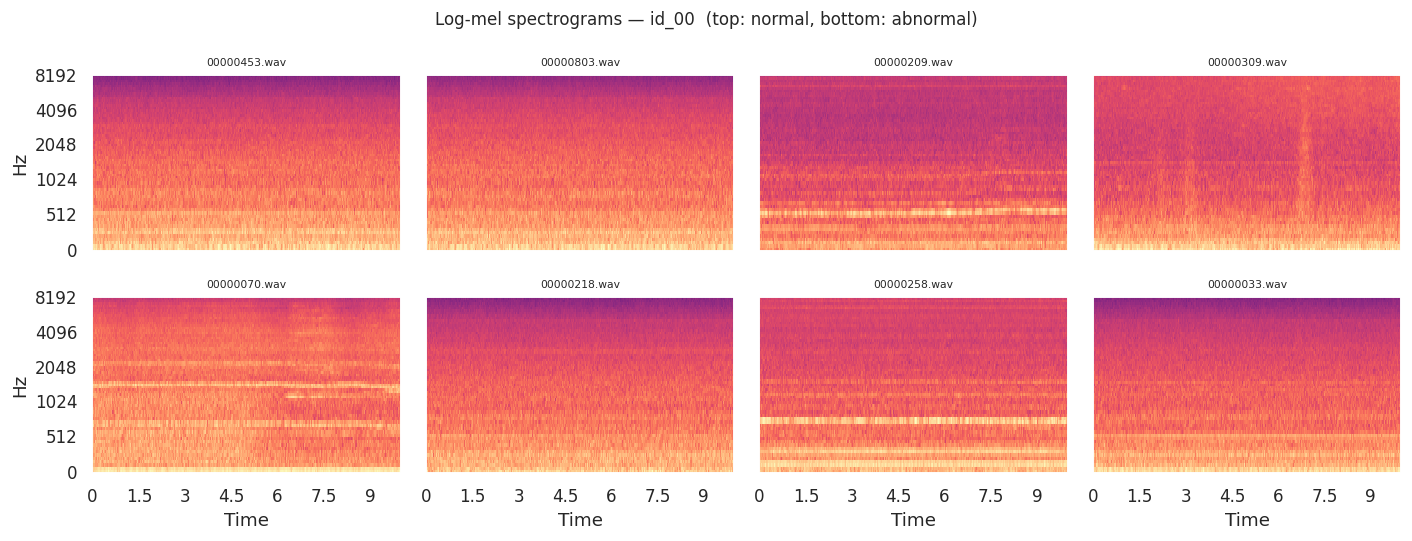

In [18]:
machine_id = 'id_00'
n_cols = 4

fig, axes = plt.subplots(2, n_cols, figsize=(13, 5))
fig.suptitle(f'Log-mel spectrograms — {machine_id}  (top: normal, bottom: abnormal)', fontsize=11)

for row_idx, label in enumerate(('normal', 'abnormal')):
    paths = manifest[(manifest['machine_id'] == machine_id) &
                     (manifest['label'] == label)]['path'].sample(n_cols, random_state=SEED).tolist()
    for col_idx, path in enumerate(paths):
        ax = axes[row_idx, col_idx]
        y = load_mono(path)
        S_db = compute_log_mel(y)
        librosa.display.specshow(S_db, sr=SR, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='mel', ax=ax,
                                  cmap='magma', vmin=-80, vmax=0)
        ax.set_title(path.name, fontsize=7)
        ax.label_outer()

plt.tight_layout()
plt.show()

## 10 — EDA Summary & Next Steps

### Key findings
| Finding | Implication |
|---|---|
| ~3:1 normal/abnormal ratio | Use AUC-ROC, not accuracy; do NOT oversample abnormal for training |
| 8-channel recordings | Mix to mono or pick channel 0; revisit with beamforming if baseline is weak |
| 4 distinct machine IDs | Train/evaluate **per ID** to avoid learning machine identity |
| All clips 10 s / 16 kHz | No variable-length handling needed; fixed-size tensors throughout |
| Log-mel separability (PCA) | There is some apparent high variability in normal sounds |

### Recommended next steps

1. **Baseline notebook** — fit a `GaussianMixture` or `IsolationForest` on the MFCC summary features; this gives a fast AUC-ROC baseline without any deep learning.

2. **Autoencoder notebook** — train a convolutional autoencoder on log-mel patches from normal clips only; use reconstruction error as the anomaly score. This is the DCASE 2020 Task 2 official baseline approach.

3. **Self-supervised notebook** — explore contrastive or masked-prediction approaches (e.g., BYOL-A, SSAST) that learn richer representations without labels.

4. **Evaluation harness** — write a shared `evaluate(scores, labels)` function once, reuse it across all notebooks to ensure fair comparison.